<a href="https://colab.research.google.com/github/himanshu1kk/myrepo/blob/main/potato_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
print("Current working directory:", os.getcwd())

Current working directory: /content


In [ ]:
print("Files in /content:", os.listdir('/content'))

Files in /content: ['.config', 'Potatohealthy.zip', 'Late_blight', 'potato_diseases', 'drive', 'Potato___Late_blight.zip', 'Potato___Early_blight.zip', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()  # This will show the actual upload location

In [ ]:
os.makedirs('potato_diseases', exist_ok=True)

In [ ]:
!unzip -q /content/Potato___Early_blight.zip -d potato_diseases/Early_blight
# !unzip -q /content/Potato___Late_blight.zip -d potato_diseases/Late_blight
# !unzip -q /content/Potatohealthy.zip -d potato_diseases/Healthy

# Verify
print("Extracted folders:", os.listdir('potato_diseases'))

replace potato_diseases/Early_blight/Potato___Early_blight/001187a0-57ab-4329-baff-e7246a9edeb0___RS_Early.B 8178.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: Extracted folders: ['Early_blight', 'Healthy']


In [ ]:
potato_dir = '/content/potato_diseases'
if os.path.exists(potato_dir):
    print("Files in potato_diseases:", os.listdir(potato_dir))
else:
  print("not found")

Files in potato_diseases: ['Late_blight', 'Early_blight', 'Healthy']


In [ ]:
!unzip -o /content/Potato___Late_blight.zip -d /content/potato_diseases/Late_blight

Archive:  /content/Potato___Late_blight.zip
   creating: /content/potato_diseases/Late_blight/Potato___Late_blight/
  inflating: /content/potato_diseases/Late_blight/Potato___Late_blight/0051e5e8-d1c4-4a84-bf3a-a426cdad6285___RS_LB 4640.JPG  
  inflating: /content/potato_diseases/Late_blight/Potato___Late_blight/00695906-210d-4a9d-822e-986a17384115___RS_LB 4026.JPG  
  inflating: /content/potato_diseases/Late_blight/Potato___Late_blight/006cc01a-1888-4326-9b62-a65cb55a6377___RS_LB 5207.JPG  
  inflating: /content/potato_diseases/Late_blight/Potato___Late_blight/0085ef03-aec3-431a-99a1-de286e10c0cf___RS_LB 2949.JPG  
  inflating: /content/potato_diseases/Late_blight/Potato___Late_blight/00b1f292-23dd-44d4-aad3-c1ffb6a6ad5a___RS_LB 4479.JPG  
  inflating: /content/potato_diseases/Late_blight/Potato___Late_blight/0114b195-844c-4978-93a9-b0d5aae010f1___RS_LB 2738.JPG  
  inflating: /content/potato_diseases/Late_blight/Potato___Late_blight/01270f5c-a44b-4da7-9398-289088c197ab___RS_LB 2517.J

In [ ]:
!unzip /content/Potatohealthy.zip -d /content/Healthy

Archive:  /content/Potatohealthy.zip
   creating: /content/Healthy/Potatohealthy/
  inflating: /content/Healthy/Potatohealthy/00fc2ee5-729f-4757-8aeb-65c3355874f2___RS_HL 1864.JPG  
  inflating: /content/Healthy/Potatohealthy/03da9931-e514-4cc7-b04a-8f474a133ce5___RS_HL 1830.JPG  
  inflating: /content/Healthy/Potatohealthy/04481ca2-f94c-457e-b785-1ac05800b7ec___RS_HL 1930.JPG  
  inflating: /content/Healthy/Potatohealthy/046641c1-f837-49eb-b5f2-4109910a027c___RS_HL 1878.JPG  
  inflating: /content/Healthy/Potatohealthy/07dfb451-4378-49d1-b699-33a5fc49ff07___RS_HL 5399.JPG  
  inflating: /content/Healthy/Potatohealthy/0b3e5032-8ae8-49ac-8157-a1cac3df01dd___RS_HL 1817.JPG  
  inflating: /content/Healthy/Potatohealthy/0be9d721-82f5-42c3-b535-7494afe01dbe___RS_HL 1814.JPG  
  inflating: /content/Healthy/Potatohealthy/0f4ebc5a-d646-436a-919d-961342997cde___RS_HL 4183.JPG  
  inflating: /content/Healthy/Potatohealthy/1106c3fc-92cb-41a6-a6c6-8f08b9b45108___RS_HL 1914.JPG  
  inflating: /cont

In [ ]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [ ]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/potato_diseases",  # Updated path
    image_size=(256, 256),
    batch_size=32,
    shuffle=True,
    seed=42,
)

Found 2152 files belonging to 3 classes.


In [ ]:
class_names = dataset.class_names
class_names

#early_blight = 0
#health = 1
#late_blight = 2

['Early_blight', 'Healthy', 'Late_blight']

In [ ]:
a = 2152/32
a

67.25

In [ ]:
len(dataset) #this is because the each dataset has a batch size of 32 so their will be total of 68 batches each of batch size 32 ..1 batch has 32 images

68

In [ ]:
for image_batch,labels_batch in dataset.take(1):
  print(image_batch.shape)
  print(labels_batch.numpy())

(32, 256, 256, 3)
[2 2 2 2 2 0 0 2 2 2 1 0 0 1 2 0 0 2 0 0 2 0 0 0 2 0 0 2 0 2 2 0]


Label: Late_blight


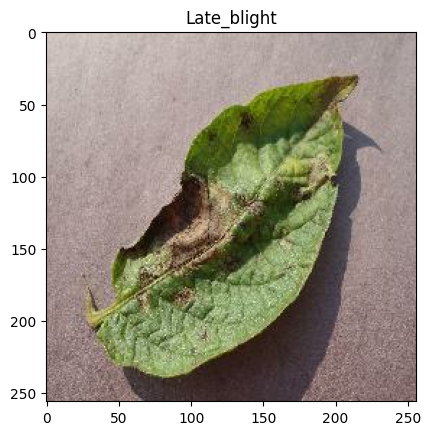

In [ ]:
for image_batch,labels_batch in dataset.take(1):
  plt.imshow(image_batch[0].numpy().astype("uint8"))
  plt.title(class_names[labels_batch[0]])
  print("Label:",class_names[labels_batch[0]])


In [ ]:
train_size  =0.8

train_ds = dataset.take(54)

len(train_ds)




54

In [ ]:
test_ds = dataset.skip(54)
len(test_ds)


14

In [ ]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [ ]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)


In [ ]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(256, 256),  # Fixed! No "experimental"
    layers.Rescaling(1.0/255)
])

In [ ]:
data_augumentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [ ]:
#Now we will use CNN for training the images
model = models.Sequential([
    resize_and_rescale,
    data_augumentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32,256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32,256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32,256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32,256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32,256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32,256, 256, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')


])

model.build(input_shape=(32,256, 256, 3))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer = 'adam',
    loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    epochs = 15,
    batch_size = 32,
    validation_data = val_ds
)

Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.5315 - loss: 0.9141 - val_accuracy: 0.7552 - val_loss: 0.6471
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.7200 - loss: 0.6616 - val_accuracy: 0.8125 - val_loss: 0.4879
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.8129 - loss: 0.4591 - val_accuracy: 0.8281 - val_loss: 0.4143
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8701 - loss: 0.3516 - val_accuracy: 0.9062 - val_loss: 0.2730
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9005 - loss: 0.2497 - val_accuracy: 0.9427 - val_loss: 0.1911
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9141 - loss: 0.2257 - val_accuracy: 0.8854 - val_loss: 0.2078
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8807 - loss: 0.2818 - val_accuracy: 0.9531 - val_loss: 0.1240
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9290 - loss: 0.1891 - val_accuracy: 0.9427 - 

In [ ]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8510 - loss: 0.4882


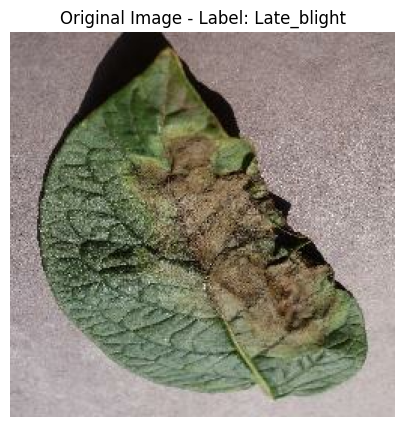

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


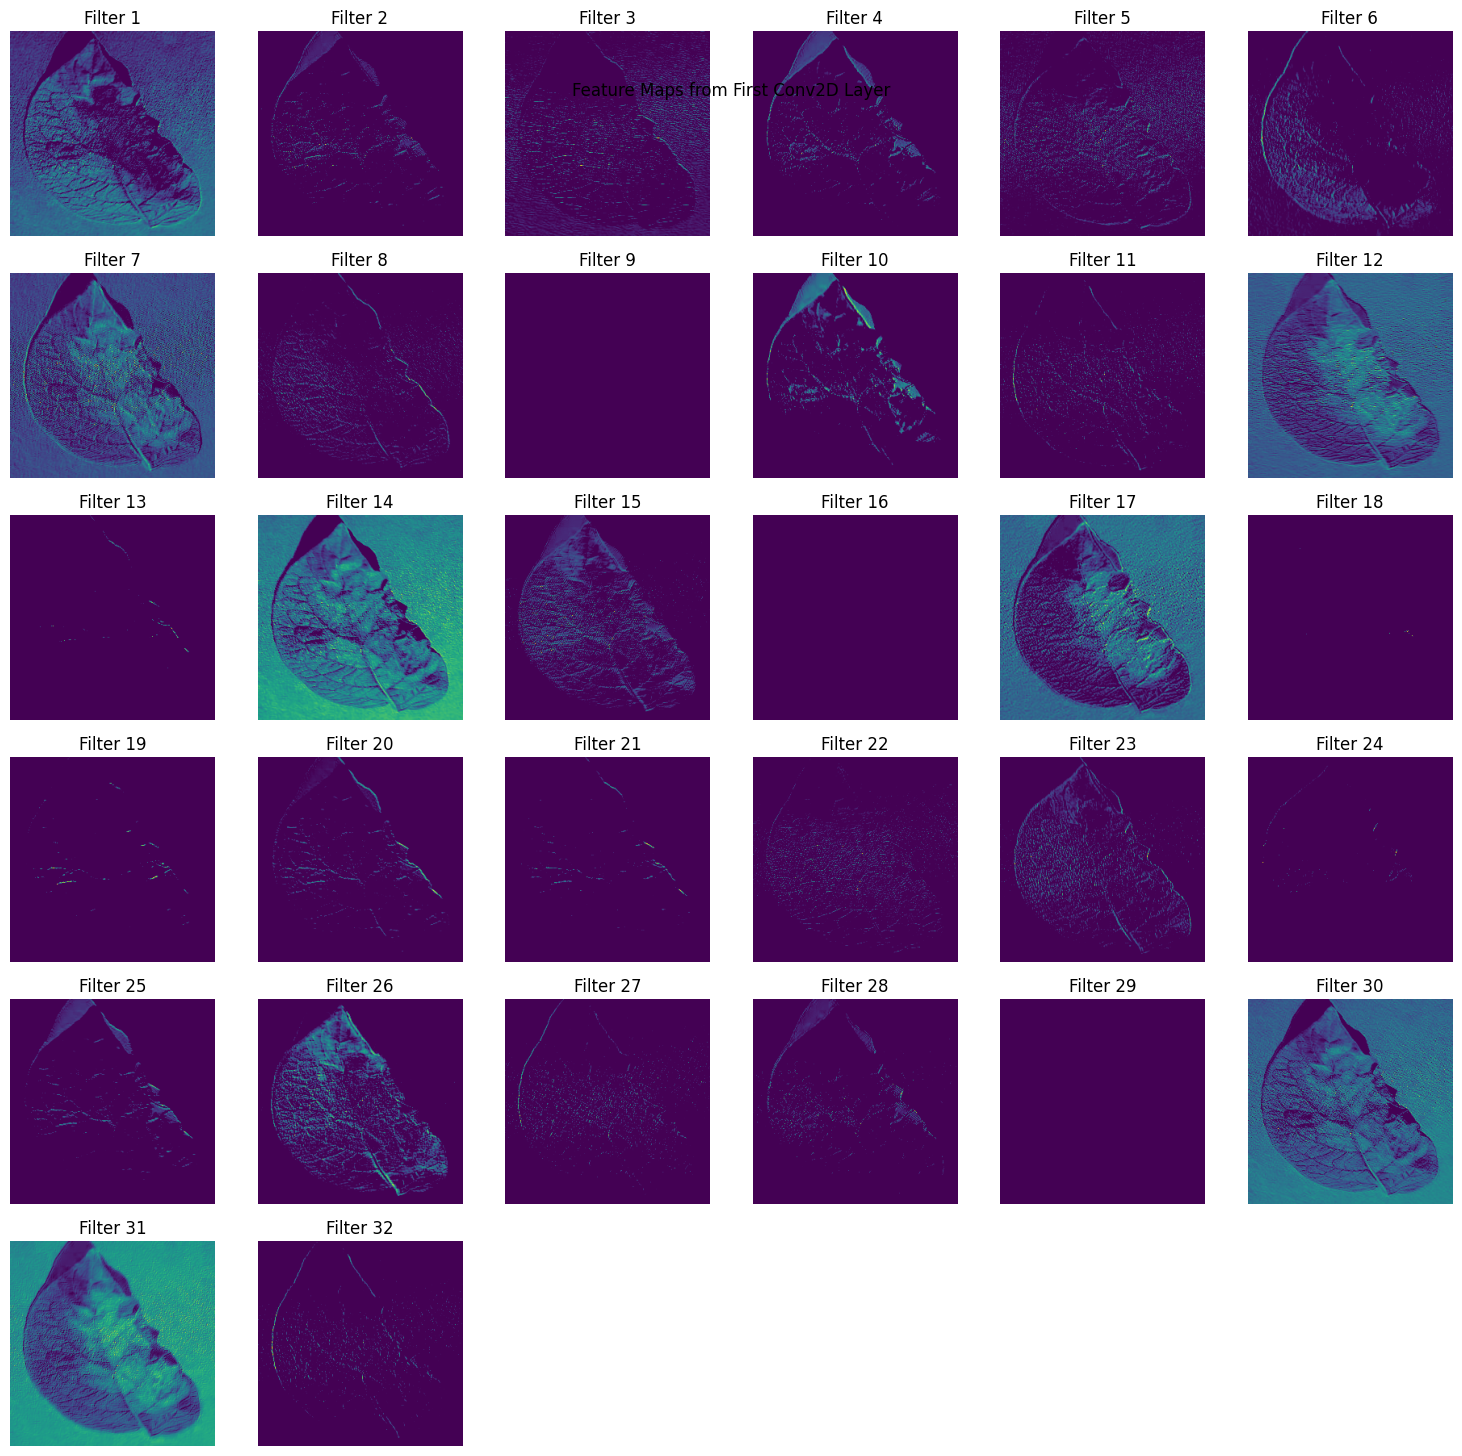

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a sample image from test dataset
for images_batch, labels_batch in test_ds.take(1):
    sample_image = images_batch[0].numpy().astype('uint8')
    sample_label = labels_batch[0].numpy()

# Display original image
plt.figure(figsize=(5,5))
plt.imshow(sample_image)
plt.title(f"Original Image - Label: {class_names[sample_label]}")
plt.axis('off')
plt.show()

# Create a model that outputs the first convolutional layer's activations
layer_name = 'conv2d'  # Name of your first Conv2D layer
feature_extractor = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer(layer_name).output
)

# Get the feature maps
input_image = np.expand_dims(sample_image, axis=0)  # Add batch dimension
feature_maps = feature_extractor.predict(input_image)

# Plot all 32 feature maps
plt.figure(figsize=(15, 15))
for i in range(32):
    plt.subplot(6, 6, i+1)  # 6x6 grid (we have 32 filters)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Filter {i+1}')
plt.suptitle('Feature Maps from First Conv2D Layer', y=0.92)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


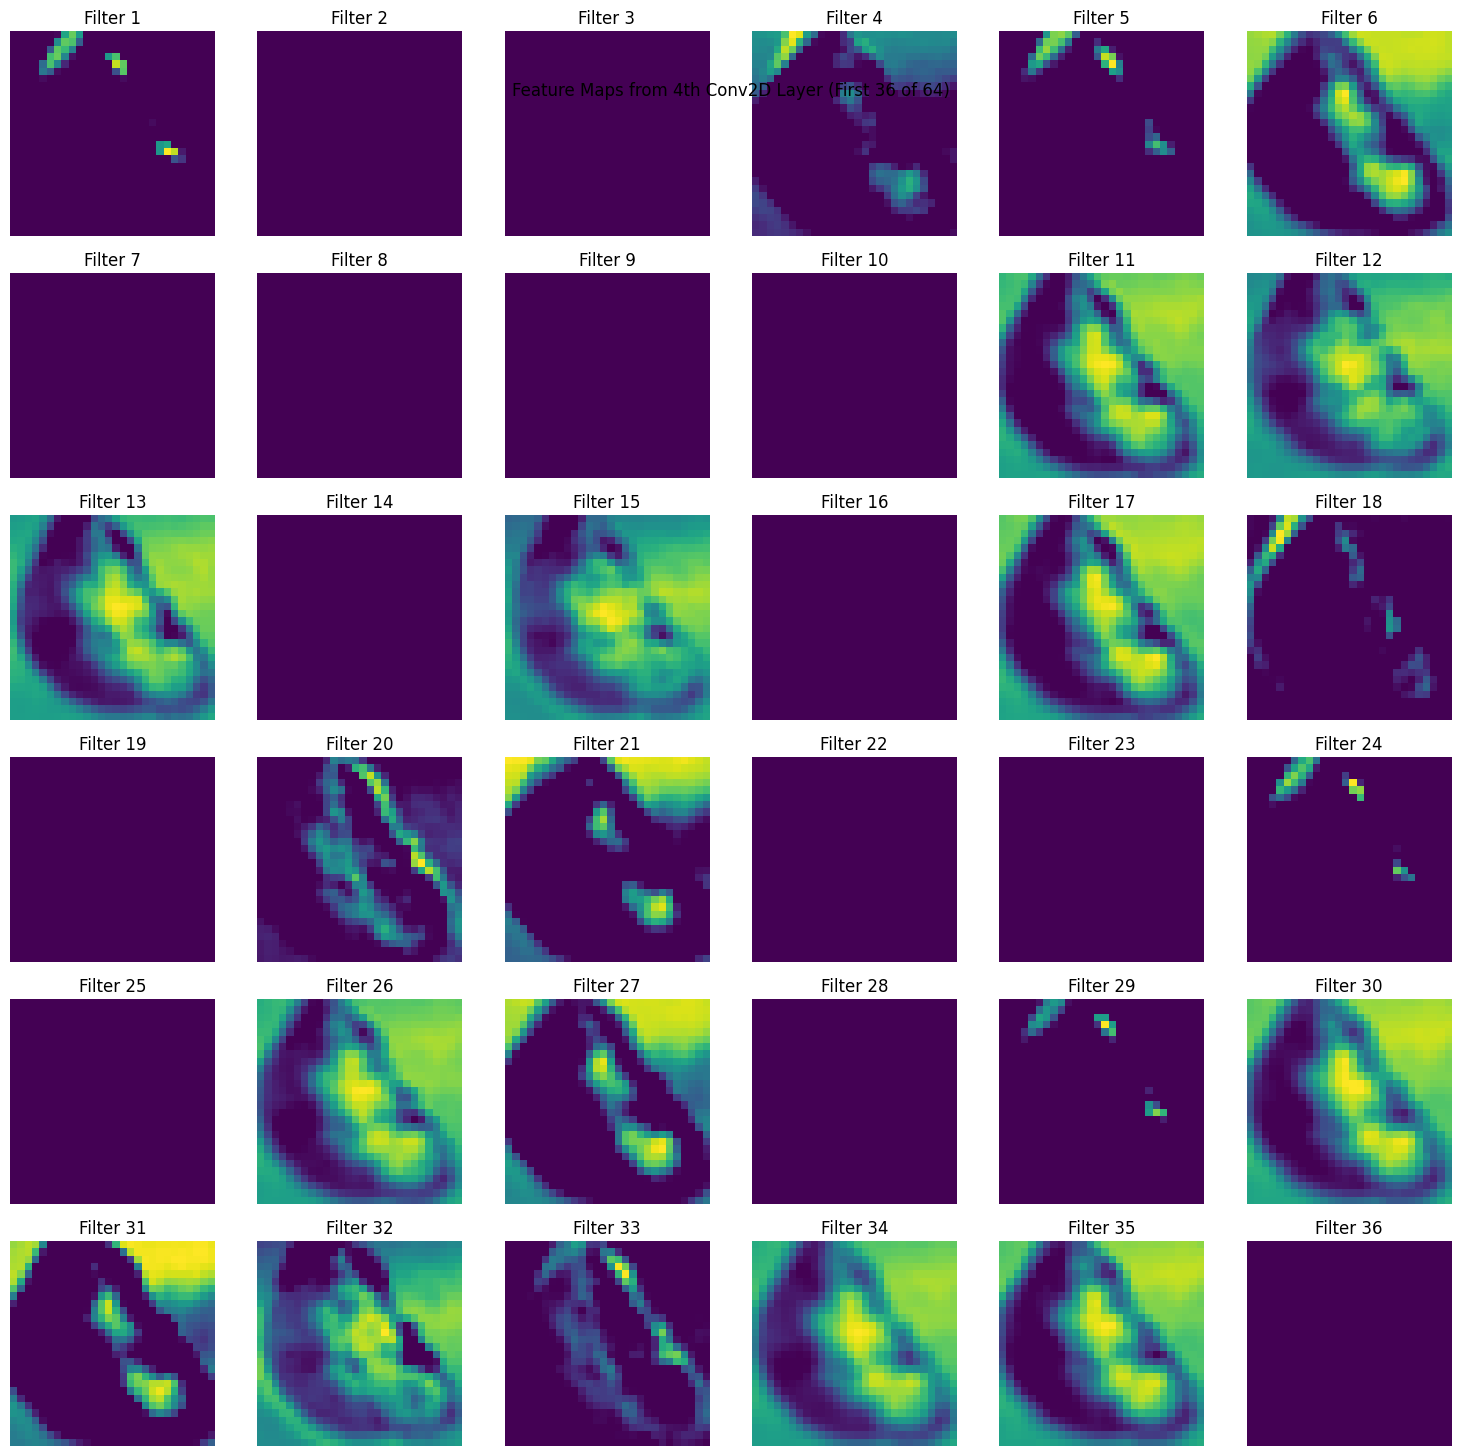

In [ ]:
# Get layer name (adjust if your layer names are different)
layer_name = 'conv2d_3'  # 4th Conv2D layer (0-indexed as conv2d, conv2d_1, conv2d_2, conv2d_3)

# Create feature extractor for 4th Conv2D layer
feature_extractor_4 = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer(layer_name).output
)

# Get feature maps
feature_maps_4 = feature_extractor_4.predict(input_image)

# Plot first 36 feature maps (4th layer has 64 filters)
plt.figure(figsize=(15, 15))
for i in range(36):  # Showing first 36 of 64 filters
    plt.subplot(6, 6, i+1)
    plt.imshow(feature_maps_4[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Filter {i+1}')
plt.suptitle('Feature Maps from 4th Conv2D Layer (First 36 of 64)', y=0.92)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


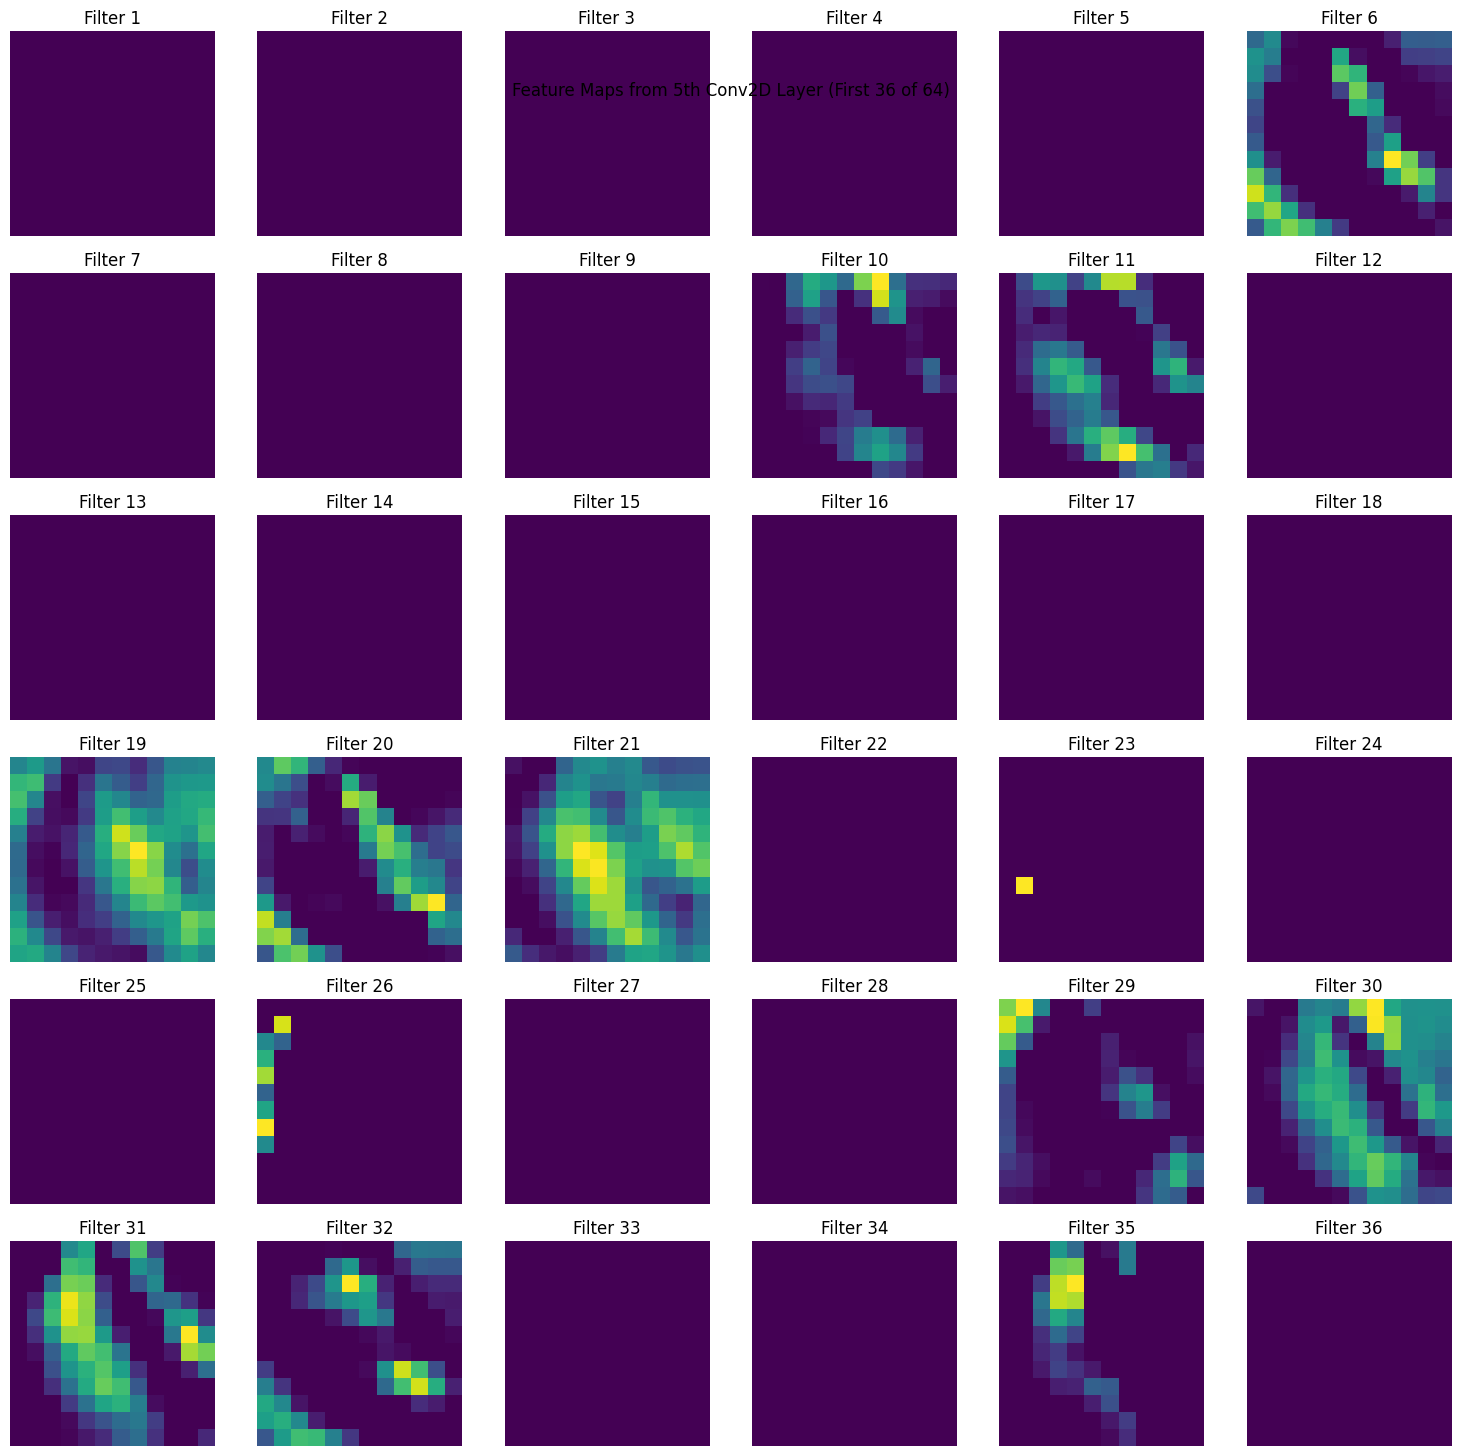

In [ ]:
# Get layer name
layer_name = 'conv2d_4'  # 5th Conv2D layer

# Create feature extractor for 5th Conv2D layer
feature_extractor_5 = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer(layer_name).output
)

# Get feature maps
feature_maps_5 = feature_extractor_5.predict(input_image)

# Plot first 36 feature maps
plt.figure(figsize=(15, 15))
for i in range(36):  # Showing first 36 of 64 filters
    plt.subplot(6, 6, i+1)
    plt.imshow(feature_maps_5[0, :, :, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Filter {i+1}')
plt.suptitle('Feature Maps from 5th Conv2D Layer (First 36 of 64)', y=0.92)
plt.tight_layout()
plt.show()

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

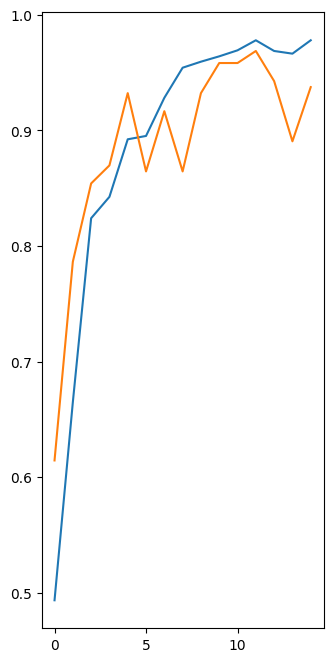

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(15), acc, label='Training Accuracy')
plt.plot(range(15), val_acc, label='Validation Accuracy')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

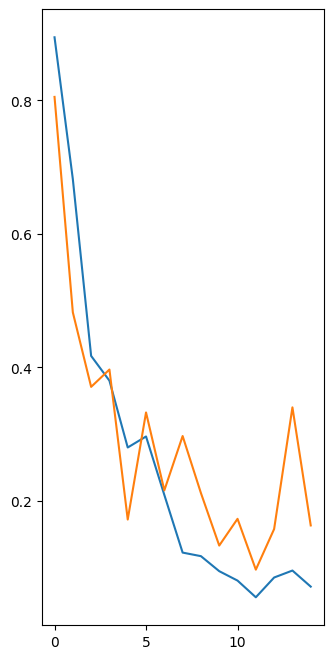

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(15), loss, label='Training Loss')
plt.plot(range(15), val_loss, label='Validation Loss')
plt

first image to predict
actual label: Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
prediction label :  Late_blight


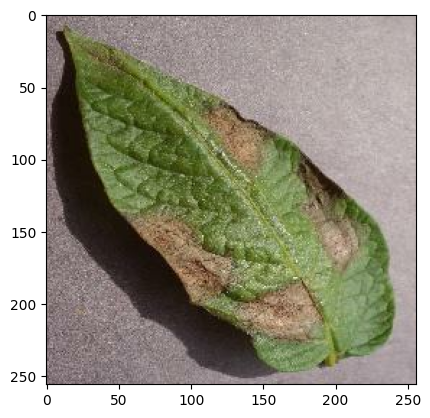

In [ ]:
import numpy as np
for images_batch , labels_batch in test_ds.take(1):
  first_image = images_batch[0].numpy().astype('uint8')
  first_label = labels_batch[0].numpy()

  print("first image to predict")
  plt.imshow(first_image)
  print("actual label:",class_names[first_label])

  batch_prediction = model.predict(images_batch)

  print("prediction label : ", class_names[np.argmax(batch_prediction[0])])

In [ ]:
export_path = '/content/exported_model'

In [ ]:
os.makedirs(export_path, exist_ok=True)

In [ ]:
model.save('/content/exported_model.keras')

In [ ]:
from google.colab import files
files.download('/content/exported_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install nest_asyncio

In [ ]:
# Install necessary packages
!pip install fastapi uvicorn pyngrok pillow
import nest_asyncio

import tensorflow as tf
from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse
from PIL import Image
import numpy as np
import uvicorn
from pyngrok import ngrok



# Paste your authtoken here
ngrok.set_auth_token("2yDh9lkKOKekkoccoYtHHapkAPr_7CGGyznnbvEM91UNd1jnP")

# Load your model (adjust path as needed)
model = tf.keras.models.load_model('/content/exported_model.keras')

class_names = ['Early_blight', 'Healthy', 'Late_blight']  # Adjust as per your training order

app = FastAPI()

@app.post("/predict/")
async def predict(file: UploadFile = File(...)):
    # Read image file
    contents = await file.read()
    image = Image.open(BytesIO(contents)).convert("RGB")
    image = image.resize((256, 256))
    img_array = np.array(image) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Shape: (1, 256, 256, 3)

    # Predict
    preds = model.predict(img_array)
    pred_class = class_names[np.argmax(preds[0])]
    confidence = float(np.max(preds[0]))

    return JSONResponse({"predicted_class": pred_class, "confidence": confidence})

# Start uvicorn server via pyngrok
public_url = ngrok.connect(8000)
print(f"FastAPI is available on: {public_url}")

nest_asyncio.apply()
uvicorn.run(app, host="0.0.0.0", port=8000)

/usr/lib/python3.11/pathlib.py:540: RuntimeWarning: coroutine 'Server.serve' was never awaited
  return self._str


FastAPI is available on: NgrokTunnel: "https://0c80-34-124-160-12.ngrok-free.app" -> "http://localhost:8000"


INFO:     Started server process [344]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     2409:40d2:12fa:cbd2:d1f4:5054:3f68:5e80:0 - "POST /predict/ HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/fastapi/applications.py", line 1054, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.11/dist-packages/starlette/applications.py", line 112, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.11/dist-packages/starlette/middleware/errors.py", line 187, in __call__
    raise exc
  File "/usr/local/lib/python3.11/dist-packages/starlette/middleware/errors.py",